In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, when, avg, expr, log1p, expm1, abs
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.types import FloatType, IntegerType
import matplotlib.pyplot as plt


In [ ]:
spark=SparkSession.builder.appName('Inspecting_healthcare').getOrCreate()

In [ ]:
url="D:/Coding_Projects/DataSets_health/2023/MUP_PHY_R25_P05_V20_D23_Geo.csv" #change it to the location of your file
data=spark.read.option('header','true').option('inferSchema','true').csv(url)

In [ ]:
data.show()

+--------------------+-------------------+---------------------+--------+--------------------+--------------+-------------+-----------------+---------+---------+------------------+--------------+------------------+-----------------+------------------+
|Rndrng_Prvdr_Geo_Lvl|Rndrng_Prvdr_Geo_Cd|Rndrng_Prvdr_Geo_Desc|HCPCS_Cd|          HCPCS_Desc|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Avg_Mdcr_Alowd_Amt|Avg_Mdcr_Pymt_Amt|Avg_Mdcr_Stdzd_Amt|
+--------------------+-------------------+---------------------+--------+--------------------+--------------+-------------+-----------------+---------+---------+------------------+--------------+------------------+-----------------+------------------+
|            National|               NULL|             National|   0001A|Intramuscular adm...|             N|            O|              297|      707|    712.0|               712|   53.14877809|      39.570042135|     39.570042135|      40.118

In [ ]:
data=data.filter(col('Rndrng_Prvdr_Geo_Lvl')!='National')
data=data.dropna()
data.show()

+--------------------+-------------------+---------------------+--------+--------------------+--------------+-------------+-----------------+---------+---------+------------------+--------------+------------------+-----------------+------------------+
|Rndrng_Prvdr_Geo_Lvl|Rndrng_Prvdr_Geo_Cd|Rndrng_Prvdr_Geo_Desc|HCPCS_Cd|          HCPCS_Desc|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|Avg_Mdcr_Alowd_Amt|Avg_Mdcr_Pymt_Amt|Avg_Mdcr_Stdzd_Amt|
+--------------------+-------------------+---------------------+--------+--------------------+--------------+-------------+-----------------+---------+---------+------------------+--------------+------------------+-----------------+------------------+
|               State|                 01|              Alabama|   0003A|Intramuscular adm...|             N|            O|                5|       12|     12.0|                12|          40.0|              38.0|             38.0|            

In [ ]:
invalid=data.filter(expr('try_cast(Rndrng_Prvdr_Geo_Cd as int)').isNull())
invalid.groupBy('Rndrng_Prvdr_Geo_Cd','Rndrng_Prvdr_Geo_Desc').count().show()

# data.filter(col('Rndrng_Prvdr_Geo_Cd').isin('9A','9B','9C','9D','9E')).groupBy('Rndrng_Prvdr_Geo_Cd','Rndrng_Prvdr_Geo_Desc').count().show()

+-------------------+---------------------+-----+
|Rndrng_Prvdr_Geo_Cd|Rndrng_Prvdr_Geo_Desc|count|
+-------------------+---------------------+-----+
|                 9B|  Armed Forces Europe|  213|
|                 9A| Armed Forces Cent...|  169|
|                 9D|              Unknown|  230|
|                 9E|      Foreign Country|  257|
|                 9C| Armed Forces Pacific|  285|
+-------------------+---------------------+-----+



In [ ]:
#Dropping armed forces, foreign or unkown
data=data.filter(~expr('try_cast(Rndrng_Prvdr_Geo_Cd as int)').isNull())

In [ ]:
# invalid=data.filter(expr('try_cast(Rndrng_Prvdr_Geo_Cd as int)').isNull())
# invalid.groupBy('Rndrng_Prvdr_Geo_Cd','Rndrng_Prvdr_Geo_Desc').count().show()

In [ ]:
columns_gtg=[ 'Rndrng_Prvdr_Geo_Cd','HCPCS_Cd', 'HCPCS_Drug_Ind','Place_Of_Srvc','Tot_Rndrng_Prvdrs',
 'Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs','Avg_Sbmtd_Chrg']

X=data.select(columns_gtg)

In [ ]:
# X.select('Place_Of_Srvc').distinct().count()
columns_scale=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']

X=X.withColumn('Rndrng_Prvdr_Geo_Cd',expr("try_cast(Rndrng_Prvdr_Geo_Cd as int)"))
X=X.withColumn('Avg_Sbmtd_Chrg',expr("try_cast(Avg_Sbmtd_Chrg as double)"))

for column in columns_scale:
    # X=X.withColumn(column,expr(f"try_cast({column} as int)"))
    X=X.withColumn(column,log1p(col(column)))


In [ ]:
columns_sindexer=['HCPCS_Cd','HCPCS_Drug_Ind','Place_Of_Srvc']
ouput_sindexer=['HCPCS_Cd_indexed','HCPCS_Drug_Ind_indexed','Place_Of_Srvc_indexed']

#indexing
string_indexer=StringIndexer(inputCols=columns_sindexer,
                             outputCols=ouput_sindexer)

#vectorize to scale
scale_assembler=VectorAssembler(inputCols=columns_scale,
                                outputCol='scaling_features')

#scaling #check if log transfor need to be used for the other columns not just the target!!!!!
scaler=StandardScaler(inputCol='scaling_features',
                      outputCol='scaled_features')
#vectorizing everything
assembler=VectorAssembler(
    inputCols=['Rndrng_Prvdr_Geo_Cd']+ouput_sindexer+['scaled_features'],
 outputCol='Features_Col'
)

#Linear Regression
lr=LinearRegression(featuresCol='Features_Col',
                    labelCol='Avg_Sbmtd_Chrg')

#Pipeline
pipeline=Pipeline(stages=[string_indexer,scale_assembler,scaler,assembler,lr])
model=pipeline.fit(X)
new_X=model.transform(X)

In [ ]:
evaluator=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
                              predictionCol='prediction',
                              metricName='rmse')

rmse=evaluator.evaluate(new_X)

print(f'rmse: {rmse}')

rmse: 2411.479916498595


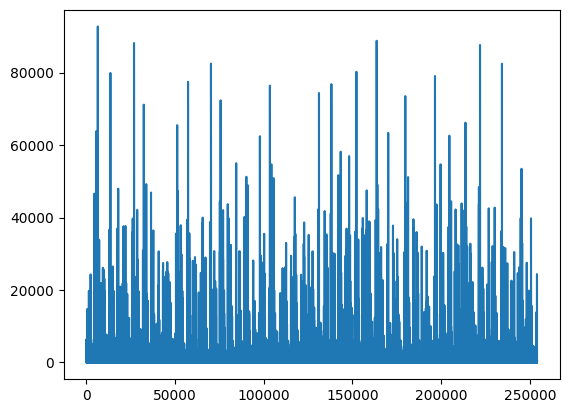

In [ ]:
new_X=new_X.withColumn('Residuals',abs(col('Avg_Sbmtd_Chrg')-col('prediction')))
residuals=new_X.select('Residuals').toPandas()

plt.plot(range(len(residuals)),residuals)

Extra Stuff

In [ ]:
# new_X=new_X.withColumn('original_pred',expm1(col('prediction')))

In [ ]:
# evaluator=RegressionEvaluator(labelCol='Avg_Sbmtd_Chrg',
#                               predictionCol='original_pred',
#                               metricName='rmse')

# rmse=evaluator.evaluate(new_X)

# print(f'rmse: {rmse}')

In [ ]:
new_X.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----------------+----------------------+---------------------+--------------------+--------------------+--------------------+------------------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|    scaling_features|     scaled_features|        Features_Col|        prediction|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----------------+----------------------+---------------------+--------------------+--------------------+--------------------+------------------+
|                  1|   0003A|             N|            O| 1.791759469228055|2.5649493574615367|2.5649493574615367

In [ ]:
#Utah:49
utah=new_X.filter(col('Rndrng_Prvdr_Geo_Cd')==49)

In [ ]:
utah.show()

+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----------------+----------------------+---------------------+--------------------+--------------------+--------------------+------------------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc| Tot_Rndrng_Prvdrs|         Tot_Benes|         Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|    scaling_features|     scaled_features|        Features_Col|        prediction|
+-------------------+--------+--------------+-------------+------------------+------------------+------------------+------------------+--------------+----------------+----------------------+---------------------+--------------------+--------------------+--------------------+------------------+
|                 49|   0004A|             N|            O|1.6094379124341003|2.9444389791664403|2.9444389791664403

In [ ]:
# utah=utah.limit(5000)
# utah.count()

In [ ]:
null_counts = new_X.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in new_X.columns
])

null_counts.show()

+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----------------+----------------------+---------------------+----------------+---------------+------------+----------+
|Rndrng_Prvdr_Geo_Cd|HCPCS_Cd|HCPCS_Drug_Ind|Place_Of_Srvc|Tot_Rndrng_Prvdrs|Tot_Benes|Tot_Srvcs|Tot_Bene_Day_Srvcs|Avg_Sbmtd_Chrg|HCPCS_Cd_indexed|HCPCS_Drug_Ind_indexed|Place_Of_Srvc_indexed|scaling_features|scaled_features|Features_Col|prediction|
+-------------------+--------+--------------+-------------+-----------------+---------+---------+------------------+--------------+----------------+----------------------+---------------------+----------------+---------------+------------+----------+
|                  0|       0|             0|            0|                0|        0|        0|                 0|             0|               0|                     0|                    0|               0|              0|           0|        

array([[<Axes: title={'center': 'Tot_Rndrng_Prvdrs'}>]], dtype=object)

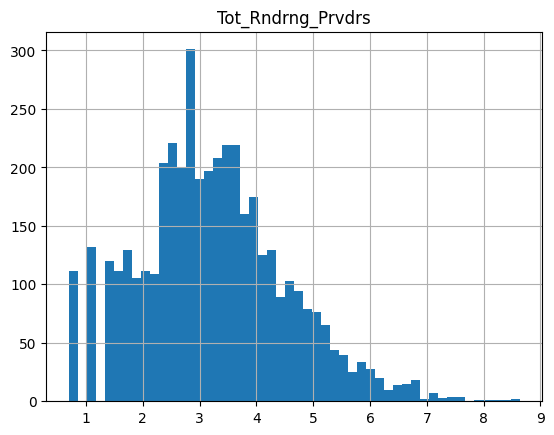

In [ ]:
columns_scale=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
utah.select("Tot_Rndrng_Prvdrs").toPandas().hist(bins=50)

array([[<Axes: title={'center': 'Avg_Sbmtd_Chrg'}>]], dtype=object)

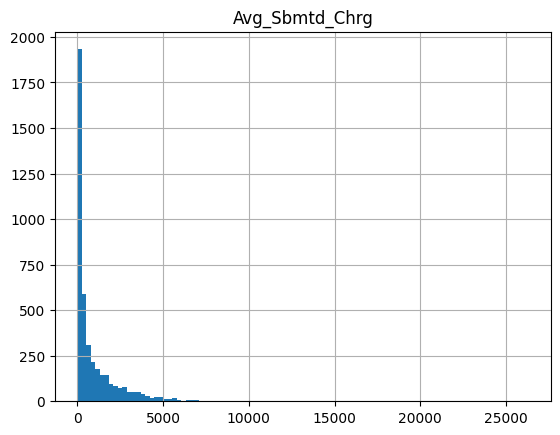

In [ ]:
utah.select("Avg_Sbmtd_Chrg").toPandas().hist(bins=100)

In [ ]:
utah.select('target').toPandas().hist(bins=100)

{"ts": "2026-03-18 13:30:52.710", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `target` cannot be resolved. Did you mean one of the following? [`Tot_Benes`, `Tot_Srvcs`, `HCPCS_Cd`, `prediction`, `Features_Col`]. SQLSTATE: 42703", "context": {"file": "jdk.internal.reflect.GeneratedMethodAccessor103.invoke(Unknown Source)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o3202.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `target` cannot be resolved. Did you mean one of the following? [`Tot_Benes`, `Tot_Srvcs`, `HCPCS_Cd`, `prediction`, `Features_Col`]. SQLSTATE: 42703;\n'Project ['target]\n+- Filter (Rndrng_Prvdr_Geo_Cd#4785 = 49)\n   +- Project [Rndrng_Prvdr_Geo_Cd#4785, H

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `target` cannot be resolved. Did you mean one of the following? [`Tot_Benes`, `Tot_Srvcs`, `HCPCS_Cd`, `prediction`, `Features_Col`]. SQLSTATE: 42703;
'Project ['target]
+- Filter (Rndrng_Prvdr_Geo_Cd#4785 = 49)
   +- Project [Rndrng_Prvdr_Geo_Cd#4785, HCPCS_Cd#4606, HCPCS_Drug_Ind#4608, Place_Of_Srvc#4609, Tot_Rndrng_Prvdrs#4787, Tot_Benes#4788, Tot_Srvcs#4789, Tot_Bene_Day_Srvcs#4790, Avg_Sbmtd_Chrg#4786, HCPCS_Cd_indexed#5077, HCPCS_Drug_Ind_indexed#5078, Place_Of_Srvc_indexed#5079, scaling_features#5090, scaled_features#5094, Features_Col#5100, UDF(Features_Col#5100) AS prediction#5103]
      +- Project [Rndrng_Prvdr_Geo_Cd#4785, HCPCS_Cd#4606, HCPCS_Drug_Ind#4608, Place_Of_Srvc#4609, Tot_Rndrng_Prvdrs#4787, Tot_Benes#4788, Tot_Srvcs#4789, Tot_Bene_Day_Srvcs#4790, Avg_Sbmtd_Chrg#4786, HCPCS_Cd_indexed#5077, HCPCS_Drug_Ind_indexed#5078, Place_Of_Srvc_indexed#5079, scaling_featu

In [ ]:
utah.describe('Avg_Sbmtd_Chrg').show()

+-------+------------------+
|summary|    Avg_Sbmtd_Chrg|
+-------+------------------+
|  count|              4256|
|   mean|1033.7673004322714|
| stddev| 1881.693028458622|
|    min|              0.01|
|    max|      26298.604385|
+-------+------------------+

